Downloading modules and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import gspread

gc = gspread.service_account(filename=r'C:\Users\aser\OneDrive\Документы\Python\Python_practice\Work space\portfolio\first-scarab-391311-91c10fb2730e.json')

ozon_financial_statements = gc.open('OZON - отчетность')
ozon_operating_results = gc.open('OZON - показатели деятельности')
ozon_financial_ratios = gc.open('OZON - финансовые коэффициенты')

ozon_balanceq = ozon_financial_statements.get_worksheet(1) 
ozon_plq = ozon_financial_statements.get_worksheet(3)
ozon_cfq = ozon_financial_statements.get_worksheet(5)
ozon_orq = ozon_operating_results.get_worksheet(1)
ozon_fr = ozon_financial_ratios.get_worksheet(1)

val_blq = pd.DataFrame(ozon_balanceq.get('B3:ZZ45'))
val_plq = pd.DataFrame(ozon_plq.get('B3:ZZ25'))
val_cfq = pd.DataFrame(ozon_cfq.get('B3:ZZ52'))
market_place = pd.DataFrame(ozon_orq.get('B3:ZZ6')) 
metrics = pd.DataFrame(ozon_orq.get('B11:ZZ16')) 
revenue_structure = pd.DataFrame(ozon_orq.get('B21:ZZ28')) 
cost_structure = pd.DataFrame(ozon_orq.get('B34:ZZ39'))
val_fr = pd.DataFrame(ozon_fr.get('B3:ZZ42'))

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In the section below, I delete useless information, change datatypes to numeric, and set dates into friendly format.

In [2]:

val_blq.dropna(axis=0, inplace=True)
val_blq.reset_index(drop=True, inplace=True)
val_blq.iloc[1:,1:] = val_blq.iloc[1:,1:].apply(pd.to_numeric)/1000000
val_blq.iloc[0,1:] = pd.to_datetime(val_blq.iloc[0,1:], format="%d.%m.%Y").dt.date
val_blq.iloc[0,1:] = val_blq.iloc[0,1:].astype('datetime64[ns]').dt.strftime('%d-%m-%Y')

val_plq.dropna(axis=0, inplace=True)
val_plq.reset_index(drop=True, inplace=True)
val_plq.iloc[0,1:] = val_plq.iloc[0,1:].str.slice_replace(1,5,'q')
val_plq.iloc[0,1:] = val_plq.iloc[0,1:].str.slice_replace(7,10,"")
val_plq.iloc[1:,1:] = val_plq.iloc[1:,1:].apply(pd.to_numeric)/1000000

val_cfq.dropna(axis=0, inplace=True)
val_cfq.reset_index(drop=True, inplace=True)
val_cfq.iloc[0,3:] = val_cfq.iloc[0,3:].str.slice_replace(1,5, 'q')
val_cfq.iloc[0,3:] = val_cfq.iloc[0,3:].str.slice_replace(7,10, '')
val_cfq.iloc[0,1:3] = val_cfq.iloc[0,1:3].str.slice_replace(1,6,"m")
val_cfq.iloc[0,1:3] = val_cfq.iloc[0,1:3].str.slice_replace(7,10,"")
val_cfq.iloc[1:,1:] = val_cfq.iloc[1:,1:].apply(pd.to_numeric)/1000000

market_place.drop(columns=1, inplace=True)
market_place.columns = range(market_place.shape[1])
market_place.iloc[1:,1:] = market_place.iloc[1:,1:].apply(pd.to_numeric)
market_place.fillna(0, inplace=True)
market_place.iloc[0,1:] = market_place.iloc[0,1:] .str.slice_replace(1,5, 'q')
market_place.iloc[0,1:] = market_place.iloc[0,1:] .str.slice_replace(7,10, '')

metrics.iloc[:,0] = pd.concat([metrics.iloc[:,0], metrics.iloc[:,1]], ignore_index=True)
metrics.iloc[:,0] = metrics.iloc[:,0] + " " + metrics.iloc[:,1]
metrics.drop(columns=1, inplace=True)
metrics.iloc[1:,1:] = metrics.iloc[1:,1:].apply(pd.to_numeric)
metrics.fillna(0, inplace=True)
metrics.iloc[0,1:] = metrics.iloc[0,1:].str.slice_replace(1,5,'q')
metrics.iloc[0,1:] = metrics.iloc[0,1:].str.slice_replace(7,10,'')
metrics.columns = range(metrics.shape[1])

revenue_structure.drop(columns=[1,2,3], inplace=True)
revenue_structure.columns = range(revenue_structure.shape[1])
revenue_structure.iloc[1:,1:] = revenue_structure.iloc[1:,1:].apply(pd.to_numeric)/1000000 
revenue_structure.iloc[0,1:] = revenue_structure.iloc[0,1:].str.slice_replace(1,5,'q') 
revenue_structure.iloc[0,1:] = revenue_structure.iloc[0,1:].str.slice_replace(7,10,'')

cost_structure.drop(columns=[1,2,3], inplace=True)
cost_structure.columns = range(cost_structure.shape[1])
cost_structure.iloc[1:,1:] = cost_structure.iloc[1:,1:].apply(pd.to_numeric)/1000000
cost_structure.iloc[0,1:] = cost_structure.iloc[0,1:].str.slice_replace(1,5,'q')
cost_structure.iloc[0,1:] = cost_structure.iloc[0,1:].str.slice_replace(7,10,'')

val_fr.iloc[1:,1:] = val_fr.iloc[1:,1:].apply(pd.to_numeric)
val_fr.iloc[0,1:] = pd.to_datetime(val_fr.iloc[0,1:], format="%d.%m.%Y").dt.date
val_fr.iloc[0,1:] = val_fr.iloc[0,1:].astype('datetime64[ns]').dt.strftime('%d-%m-%Y')


Setting colors that will be used later and getting different date formats for visualization.

In [3]:
#Bacis settings for visualisation 
colors = ['#AFD5C1', '#E68688', '#F1D078', '#8FCCEC', '#EEAF9D', '#C4B2D6', '#A0A0A0']
font = {'fontname':'Impact'}
f_colors=['#404040','#BFBFBF', '#D9D9D9']

#Getting dates for the last 12 quarters, this period will be analysed.
quarters_analysed = 12

dates_q = val_plq.iloc[0,-quarters_analysed:]
dates_num = val_blq.iloc[0,-quarters_analysed:]
dates_line = np.arange(quarters_analysed) 



Here, I spent a lot of time visualizing different metrics of the company, so when the data is updated, I can press one button to get a full analysis of the last 12 quarters. See the graphs below the code. 

Gross Merchandise Vulue

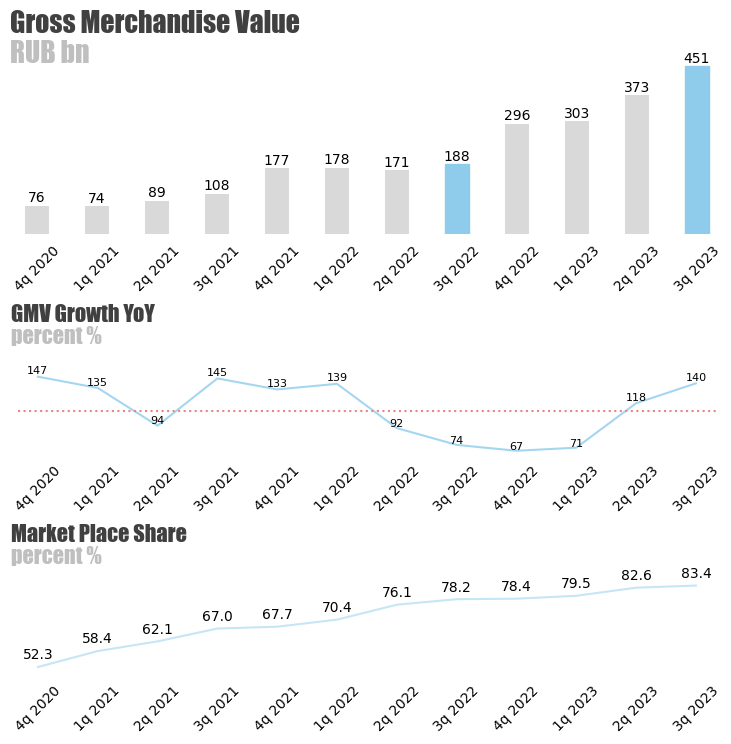

In [4]:

market_place_graph, (mpv, mpg, mpr) = plt.subplots(3,1, figsize=(9,8), height_ratios=(2,1.5,1.5))
mpv.xaxis.set_tick_params(rotation=45, labelsize=10)
mpv.yaxis.set_visible(False)
bars = mpv.bar(dates_q, market_place.iloc[1, -12:], color=f_colors[2], width=0.4)
mpv.text(-0.45, market_place.iloc[1, -12:].max()*1.2, "Gross Merchandise Value", fontsize=20, **font, color=f_colors[0])
mpv.text(-0.45, market_place.iloc[1, -12:].max()*1.02, 'RUB bn', fontsize=20, **font, color=f_colors[1])
bars[-1].set_color(colors[3])
bars[-5].set_color(colors[3])
mpv.margins(x=0.01)
mpv.xaxis.set_ticks_position('none') 
for key, spine in mpv.spines.items():
    spine.set_visible(False)
for i in range(len(dates_q)):
    mpv.text(dates_q.iloc[i], market_place.iloc[1, -12+i]+10, str(round(market_place.iloc[1, -12+i])),
            ha='center', fontsize=10)
plt.subplots_adjust(hspace=0.6)
mpr.yaxis.set_visible(False)
mpr.xaxis.set_tick_params(rotation=45, labelsize=10)
mpr.margins(x=0.03)
mpr.plot(dates_q, market_place.iloc[2, -12:], color=colors[3], alpha=0.5)
mpr.text(-0.45, market_place.iloc[2, -12:].max()*1.2,'Market Place Share', fontsize=16, **font, color=f_colors[0])
mpr.text(-0.45, market_place.iloc[2, -12:].max()*1.1,'percent %', fontsize=16, **font, color=f_colors[1])
mpr.set_ylim(market_place.iloc[2, -12:].min()*0.95, market_place.iloc[2, -12:].max()*1.2)
mpr.xaxis.set_ticks_position('none') 
for key, spine in mpr.spines.items():
    spine.set_visible(False)
for i in range(len(dates_q)):
    mpr.text(dates_q.iloc[i], market_place.iloc[2,-12+i]+3, str(round(market_place.iloc[2, -12+i],1)),
            ha='center', fontsize=10)
mpg.text(-0.45, market_place.iloc[3, -12:].max()*1.4,'GMV Growth YoY', fontsize=16, **font, color=f_colors[0])
mpg.text(-0.45, market_place.iloc[3, -12:].max()*1.24,'percent %', fontsize=16, **font, color=f_colors[1])
mpg.plot(dates_q, market_place.iloc[3, -12:], color=colors[3], alpha=0.8)
mpg.xaxis.set_tick_params(rotation=45, labelsize=10)
mpg.set_ylim(market_place.iloc[3, -12:].min()*0.95, market_place.iloc[3, -12:].max()*1.4)
mpg.yaxis.set_visible(False)
mpg.margins(x=0.03)
mpg.xaxis.set_ticks_position('none')
for i in range(len(dates_q)):
    mpg.text(dates_q.iloc[i], market_place.iloc[3, -12+i]*1.02, str(round(market_place.iloc[3, -12+i])),
             ha='center', fontsize=8)
for key, spine in mpg.spines.items():
    spine.set_visible(False)
mpg.axhline(y=market_place.iloc[3,-12:-1].mean(), color=colors[1], linestyle="dotted") 


Operating metrics

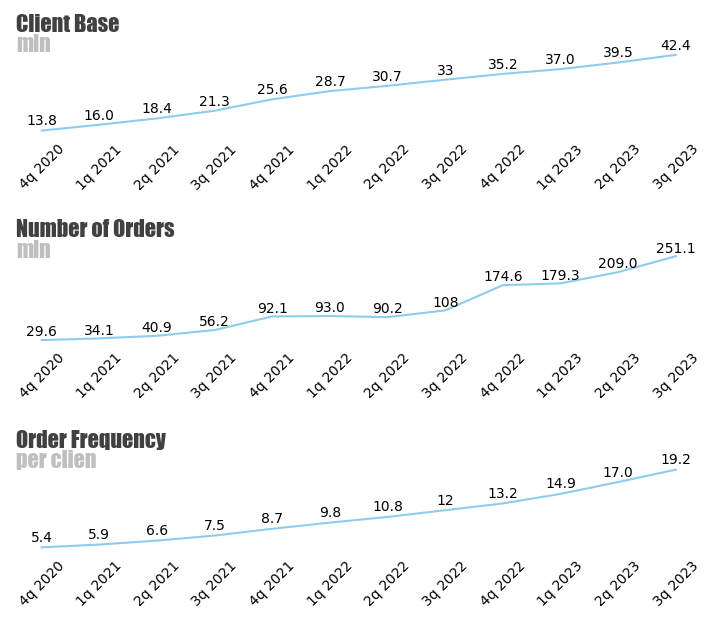

In [5]:
oper_metrics_graph, (clients, orders, avg_orders) = plt.subplots(3,1,figsize=(9,7))
clients.plot(dates_q, metrics.iloc[2, -12:], color=colors[3])
clients.xaxis.set_tick_params(rotation=45, labelsize=10)
clients.set_ylim(metrics.iloc[2, -12:].min()*0.95, metrics.iloc[2, -12:].max()*1.4)
clients.text(-0.45, metrics.iloc[2, -12:].max()*1.2,'Client Base', fontsize=16, **font, color=f_colors[0])
clients.text(-0.45, metrics.iloc[2, -12:].max()*1.03,'mln', fontsize=16, **font, color=f_colors[1])
clients.yaxis.set_visible(False)
clients.xaxis.set_ticks_position('none')
for key, spine in clients.spines.items():
    spine.set_visible(False)
plt.subplots_adjust(hspace=0.7)
for i in range(len(dates_q)):
    clients.text(dates_q.iloc[i], metrics.iloc[2, -12+i]+2, str(round(metrics.iloc[2, -12+i],1)),
                 ha='center', fontsize=10)
orders.plot(dates_q, metrics.iloc[1, -12:], color=colors[3], label='Number of orders')
orders.xaxis.set_tick_params(rotation=45, labelsize=10)
orders.set_ylim(metrics.iloc[1, -12:].min()*0.95, metrics.iloc[1, -12:].max()*1.4)
orders.text(-0.45, metrics.iloc[1, -12:].max()*1.2,'Number of Orders', fontsize=16, **font, color=f_colors[0])
orders.text(-0.45, metrics.iloc[1, -12:].max()*0.98,'mln', fontsize=16, **font, color=f_colors[1])             
orders.yaxis.set_visible(False)
orders.xaxis.set_ticks_position('none')
for key, spine in orders.spines.items():
    spine.set_visible(False)
for i in range(len(dates_q)):
    orders.text(dates_q.iloc[i], metrics.iloc[1, -12+i] +10, str(round(metrics.iloc[1, -12+i],1)),
                 ha='center', fontsize=10)
avg_orders.plot(dates_q, metrics.iloc[4, -12:], color=colors[3], label='Orders per client, avg')
avg_orders.text(-0.45, metrics.iloc[4, -12:].max()*1.2,'Order Frequency', fontsize=16, **font, color=f_colors[0])
avg_orders.text(-0.45, metrics.iloc[4, -12:].max()*1.02,'per clien', fontsize=16, **font, color=f_colors[1])             
avg_orders.yaxis.set_visible(False)
avg_orders.xaxis.set_tick_params(rotation=45, labelsize=10)
avg_orders.xaxis.set_ticks_position('none')
for key, spine in avg_orders.spines.items():
    spine.set_visible(False)
avg_orders.set_ylim(metrics.iloc[4, -12:].min()*0.95, metrics.iloc[4, -12:].max()*1.4)
for i in range(len(dates_q)):
    avg_orders.text(dates_q.iloc[i], metrics.iloc[4, -12+i]+1, str(round(metrics.iloc[4, -12+i],1)),
               ha='center', fontsize=10)


Revenue

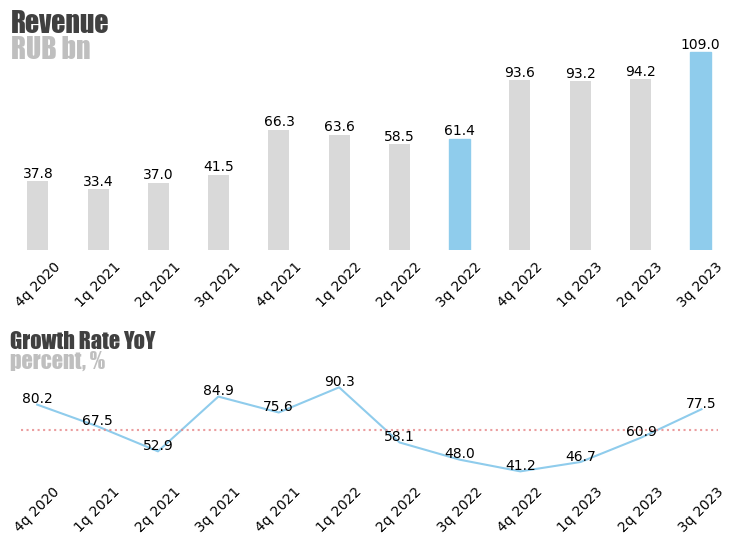

In [6]:
revenue_growth_rate = round(val_plq.iloc[1,-16:].pct_change(periods=4).drop(index=list(val_plq.iloc[1,-16:].index[0:4]))*100,1)


revenue, (rev, revg) = plt.subplots(2,1,figsize=(9,6), height_ratios=(2,1))
revenue_bars = rev.bar(dates_q, val_plq.iloc[1,-12:], color=f_colors[2], width=0.35)
revenue_bars[-1].set_color(colors[3])
revenue_bars[-5].set_color(colors[3])
rev.xaxis.set_tick_params(rotation=45, labelsize=10)
rev.set_ylim(0,val_plq.iloc[1,-12:].max()*1.2)
rev.margins(x=0.01)
rev.text(-0.45, val_plq.iloc[1,-12:].max()*1.1,'Revenue', fontsize=20, **font, color=f_colors[0])
rev.text(-0.45, val_plq.iloc[1,-12:].max()*0.97,'RUB bn', fontsize=20, **font, color=f_colors[1])             
rev.yaxis.set_visible(False)
rev.xaxis.set_ticks_position('none')
plt.subplots_adjust(hspace=0.6)
for key, spine in rev.spines.items():
    spine.set_visible(False)
for i in range(len(dates_q)):
    rev.text(dates_q.iloc[i], val_plq.iloc[1,-12+i]+2, str(round(val_plq.iloc[1,-12+i], 1)), 
             ha='center', fontsize=10)
revg.plot(dates_q, revenue_growth_rate, color=colors[3])    
revg.xaxis.set_tick_params(rotation=45, labelsize=10)
revg.set_ylim(revenue_growth_rate.min()*0.95,revenue_growth_rate.max()*1.2)
revg.text(-0.45, revenue_growth_rate.max()*1.25,'Growth Rate YoY', fontsize=16, **font, color=f_colors[0])
revg.text(-0.45, revenue_growth_rate.max()*1.12,'percent, %', fontsize=16, **font, color=f_colors[1])             
revg.yaxis.set_visible(False)
revg.margins(x=0.025)
revg.xaxis.set_ticks_position('none')
for key, spine in revg.spines.items():
    spine.set_visible(False)
for i in range(len(dates_q)):
    revg.text(dates_q.iloc[i], revenue_growth_rate.iloc[i]+1, str(revenue_growth_rate.iloc[i]),
              ha='center', fontsize=10)
revg.axhline(y=revenue_growth_rate.mean(), color=colors[1], alpha=0.8, linestyle='dotted')


Revenue breakdown

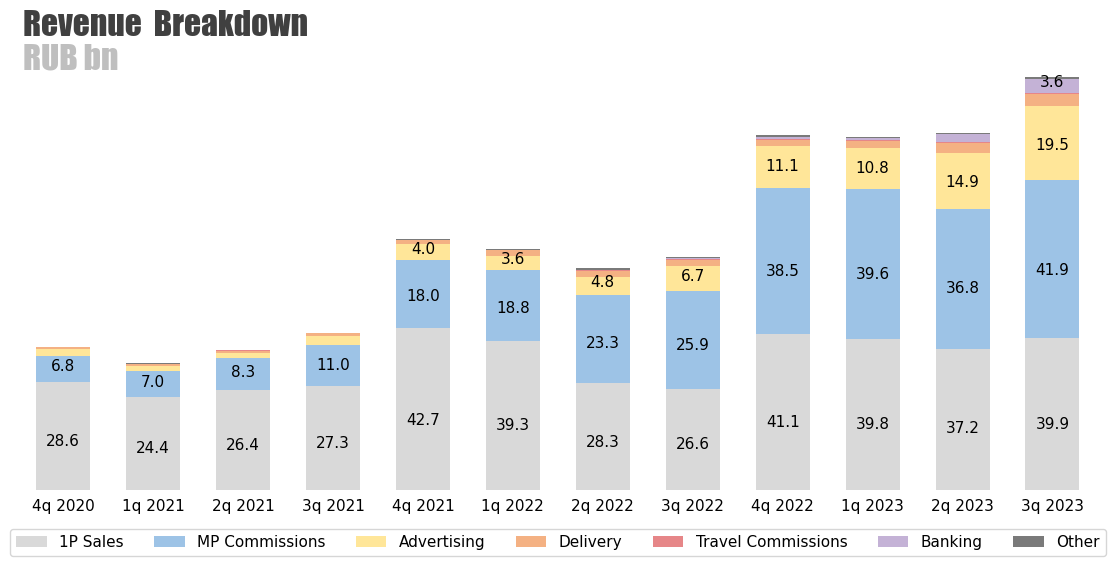

In [7]:
labels = ['1P Sales', 'MP Commissions', 'Advertising', 'Delivery', 'Travel Commissions', 'Banking', 'Other']
ozon_colors = ['#D9D9D9', '#9DC3E6', '#FFE699', '#F4B183', '#E68688','#C4B2D6', '#7A7A7A']


revenue_structure_graph, rsg = plt.subplots(figsize=(14,6))
for i in range(len(revenue_structure.iloc[1:,1:])):
    rsg.bar(dates_q, revenue_structure.iloc[1+i,-12:], color=ozon_colors[i], width=0.6, 
                 bottom=np.sum(revenue_structure.iloc[1:i+1,-12:], axis=0), label=labels[i])
rsg.text(-0.45, np.sum(revenue_structure.iloc[1:,1:], axis=0).max()*1.1,'Revenue  Breakdown', fontsize=24, **font, color=f_colors[0])
rsg.text(-0.45, np.sum(revenue_structure.iloc[1:,1:], axis=0).max()*1.02,'RUB bn', fontsize=24, **font, color=f_colors[1])             
rsg.margins(x=0.02)
rsg.tick_params(axis='x', which='major', labelsize=11)
rsg.set_ylim(0, np.sum(revenue_structure.iloc[1:,1:], axis=0).max()*1.12)
rsg.yaxis.set_visible(False)
rsg.xaxis.set_ticks_position('none')
for key, spine in rsg.spines.items():
    spine.set_visible(False)
rsg.legend(loc='lower center', bbox_to_anchor=(0.5,-0.16), ncol=7, fontsize=11)
for i in range(len(revenue_structure.iloc[1:,1:])):
    for j in range(revenue_structure.iloc[1:,-12:].shape[1]):
        if revenue_structure.iloc[1+i,-12+j] >3.5:
            rsg.text(dates_q.iloc[j], np.sum(revenue_structure.iloc[1:2+i,-12+j], axis=0) - revenue_structure.iloc[1+i,-12+j]*0.6,
                      str(round(revenue_structure.iloc[1+i, -12+j],1)), ha='center', fontsize=11)


Revenue percentage structure 

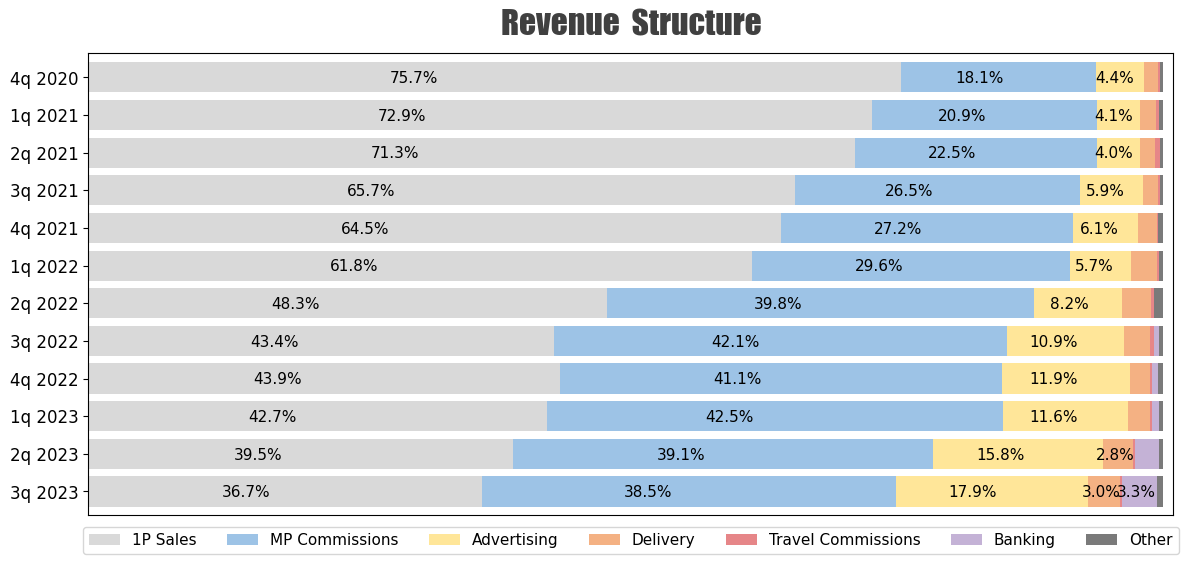

In [8]:
revenue_structure_perc = round(revenue_structure.iloc[1:,-12:] / np.sum(revenue_structure.iloc[1:,-12:], axis=0) * 100, 1)


rev_perc, rpg = plt.subplots(figsize=(14,6))
rpg.set_title('Revenue  Structure', fontsize=24,y=1.02, **font, color=f_colors[0])
rpg.invert_yaxis()
rpg.xaxis.set_visible(False)
rpg.margins(y=0.02, x=0.01)
rpg.set_yticks(dates_line, dates_q, fontsize=12)
for i in range(revenue_structure_perc.shape[0]):
    rpg.barh(dates_line, width=revenue_structure_perc.iloc[i,:], color=ozon_colors[i], label=labels[i],
             left = np.sum(revenue_structure_perc.iloc[:i,:], axis=0))
rpg.legend(loc = 'lower center', ncol=7, bbox_to_anchor=(0.5,-0.1), fontsize=11)
for i in range(revenue_structure_perc.shape[0]):
    for j in range(revenue_structure_perc.shape[1]):
        if revenue_structure_perc.iloc[i,j] >2.8:
            rpg.text(np.sum(revenue_structure_perc.iloc[:i+1,j], axis=0) - revenue_structure_perc.iloc[i,j]*0.6, dates_line[j]+0.15,
                     str(round(revenue_structure_perc.iloc[i,j], 1))+"%", ha='center', fontsize=11)
    


Operating income 

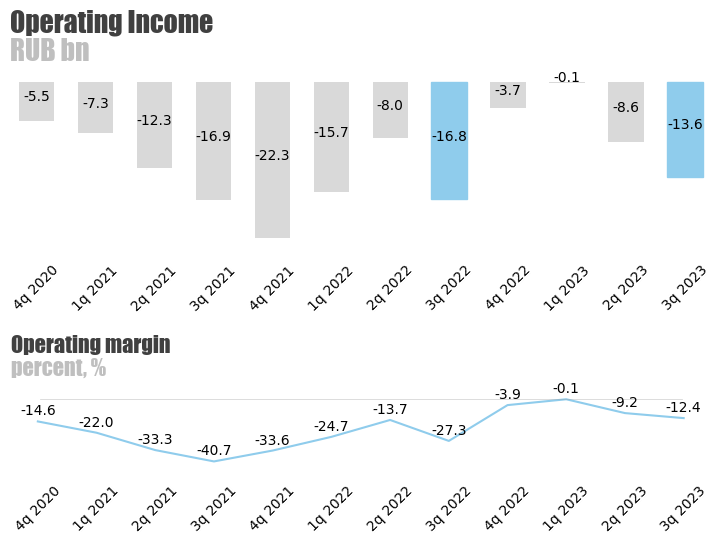

In [9]:
operating_marging = val_plq.iloc[10,-12:] / val_plq.iloc[1,-12:] *100


operatin_income, (opi, opm) = plt.subplots(2,1,figsize=(9,6), height_ratios=(2,1))
oper_bars = opi.bar(dates_q, val_plq.iloc[10,-12:], color=f_colors[2], width=0.6)
oper_bars[-1].set_color(colors[3])
oper_bars[-5].set_color(colors[3])
opi.xaxis.set_tick_params(rotation=45, labelsize=10)
opi.set_ylim(val_plq.iloc[10,-12:].min()*1.1,10)
opi.margins(x=0.01)
opi.text(-0.45, 7,'Operating Income', fontsize=20, **font, color=f_colors[0])
opi.text(-0.45, 3,'RUB bn', fontsize=20, **font, color=f_colors[1])             
opi.yaxis.set_visible(False)
opi.xaxis.set_ticks_position('none')
plt.subplots_adjust(hspace=0.55)
for key, spine in opi.spines.items():
    spine.set_visible(False)
for i in range(len(dates_q)):
    opi.text(dates_q.iloc[i], val_plq.iloc[10,-12+i]*0.5, str(round(val_plq.iloc[10,-12+i], 1)), 
             ha='center', fontsize=10)
opm.plot(dates_q, operating_marging, color=colors[3])    
opm.xaxis.set_tick_params(rotation=45, labelsize=10)
opm.set_ylim(operating_marging.min()*1.2, 30)
opm.text(-0.45, 30,'Operating margin', fontsize=16, **font, color=f_colors[0])
opm.text(-0.45, 15,'percent, %', fontsize=16, **font, color=f_colors[1])             
opm.yaxis.set_visible(False)
opm.xaxis.set_ticks_position('none')
opm.margins(x=0.04)
for key, spine in opm.spines.items():
    spine.set_visible(False)
for i in range(len(dates_q)):
    opm.text(dates_q.iloc[i], operating_marging.iloc[i]+4, str(round(operating_marging.iloc[i],1)),
              ha='center', fontsize=10)
opm.axhline(y=0, color=colors[-1], alpha=0.5, linestyle='-', linewidth=0.5, xmin=0.04, xmax=0.96)


EBITDA

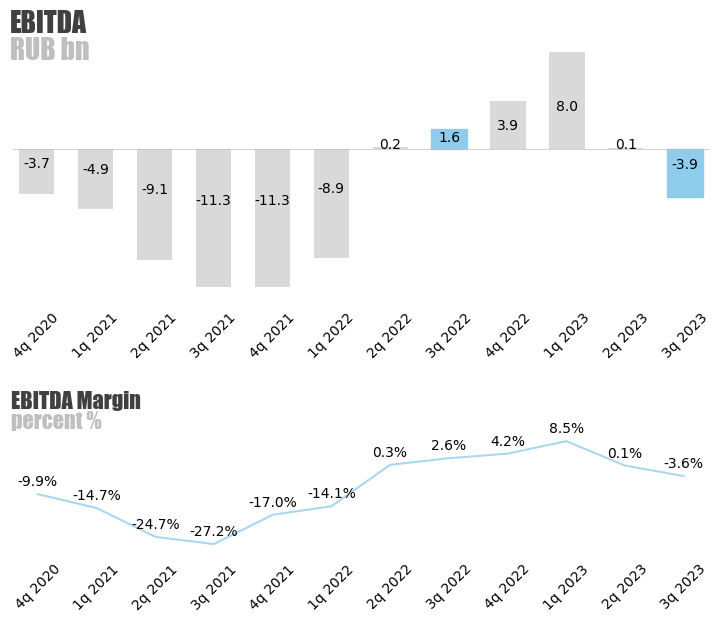

In [11]:

ebitda_margin = val_plq.iloc[-1,-12:] / val_plq.iloc[1,-12:] * 100


ebitda, (ebt, ebtm) = plt.subplots(2,1, figsize=(9,7), height_ratios=(2,1))
ebt.text(-0.45, val_plq.iloc[-1,-12:].max()*1.2,'EBITDA', fontsize=20, **font, color=f_colors[0])
ebt.text(-0.45, val_plq.iloc[-1,-12:].max()*0.92,'RUB bn', fontsize=20, **font, color=f_colors[1]) 
ebt.xaxis.set_tick_params(rotation=45, labelsize=10)
ebitda_bars = ebt.bar(dates_q, val_plq.iloc[-1,-12:], color=f_colors[2], width=0.6)
ebitda_bars[-1].set_color(colors[3])
ebitda_bars[-5].set_color(colors[3])
ebt.set_ylim(val_plq.iloc[-1,-12:].min()*1.1, val_plq.iloc[-1,-12:].max()*1.4)
for i in range(val_plq.iloc[-1,-12:].shape[0]):
    ebt.text(dates_q.iloc[i], val_plq.iloc[-1,-12+i]*0.4, str(round(val_plq.iloc[-1,-12+i], 1)),
             ha='center', fontsize=10)
ebt.yaxis.set_visible(False)
ebt.xaxis.set_ticks_position('none')
ebt.margins(x=0.01)
for key, spine in ebt.spines.items():
    spine.set_visible(False)
ebt.axhline(y=0, color=f_colors[1], linewidth=0.5)
plt.subplots_adjust(hspace=0.5)
ebtm.set_ylim(ebitda_margin.min()*1.1, 20)
ebtm.plot(dates_q, ebitda_margin, color=colors[3], alpha=0.77)
ebtm.text(-0.45, 20,'EBITDA Margin', fontsize=16, **font, color=f_colors[0])
ebtm.text(-0.45, 13,'percent %', fontsize=16, **font, color=f_colors[1]) 
ebtm.xaxis.set_tick_params(rotation=45, labelsize=10)
ebtm.yaxis.set_visible(False)
ebtm.margins(x=0.04)
ebtm.xaxis.set_ticks_position('none')
for key, spine in ebtm.spines.items():
    spine.set_visible(False)
for i in range(ebitda_margin.shape[0]):
    ebtm.text(dates_q.iloc[i], ebitda_margin.iloc[i]+3, str(round(ebitda_margin.iloc[i], 1))+"%",
              ha='center', fontsize=10)


Expenses Breakdown

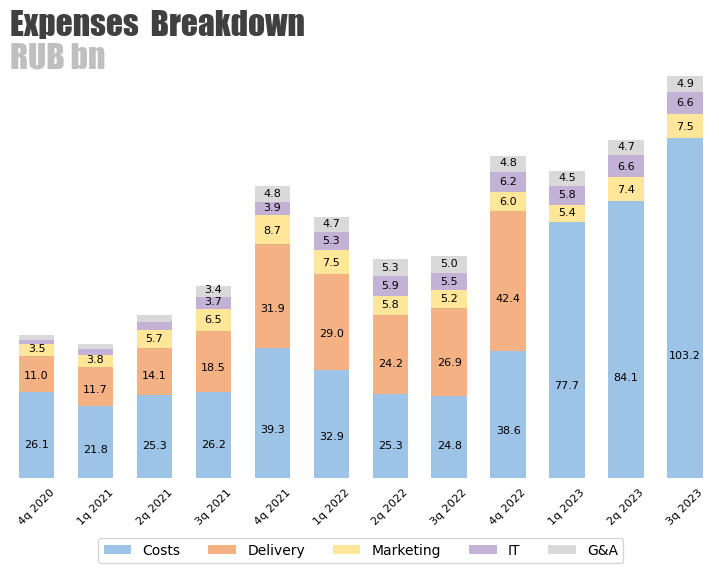

In [12]:
ozon_colors_exp = ['#9DC3E6', '#F4B183', '#FFE699', '#C4B2D6', '#D9D9D9', '#E68688']
exp_str = -val_plq.iloc[5:10,-12:]
labels_exp=['Costs', 'Delivery', 'Marketing', 'IT', 'G&A']
width_r=0.35


expenses, exp = plt.subplots(figsize=(9,6))
exp.set_ylabel('bn rubles', fontsize=10)
exp.text(-0.45, np.sum(exp_str.iloc[:,:], axis=0).max()*1.1,'Expenses  Breakdown', fontsize=24, **font, color=f_colors[0])
exp.text(-0.45, np.sum(exp_str.iloc[:,:], axis=0).max()*1.02,'RUB bn', fontsize=24, **font, color=f_colors[1])             
exp.xaxis.set_tick_params(rotation=45, labelsize=8)
for i in range(exp_str.shape[0]):
    exp.bar(dates_q, exp_str.iloc[i,:], bottom = np.sum(exp_str.iloc[:i,:], axis=0),
             color=ozon_colors_exp[i], label=labels_exp[i], width = 0.6)
exp.legend(loc='lower center', bbox_to_anchor=(0.5,-0.2),fontsize=10, ncol=5)
exp.set_ylim(0,  np.sum(exp_str.iloc[:,:], axis=0).max()*1.15)
exp.margins(x=0.01)
exp.yaxis.set_visible(False)
exp.xaxis.set_ticks_position('none')
for i in range(exp_str.shape[0]):
    for j in range(exp_str.shape[1]):
        if exp_str.iloc[i,j] > 3:
            exp.text(dates_q.iloc[j], np.sum(exp_str.iloc[:i+1,j], axis=0) - exp_str.iloc[i,j]*0.65, 
                      str(round(exp_str.iloc[i,j],1)), ha='center', fontsize=8)
for key, spine in exp.spines.items():
    spine.set_visible(False)

Profits

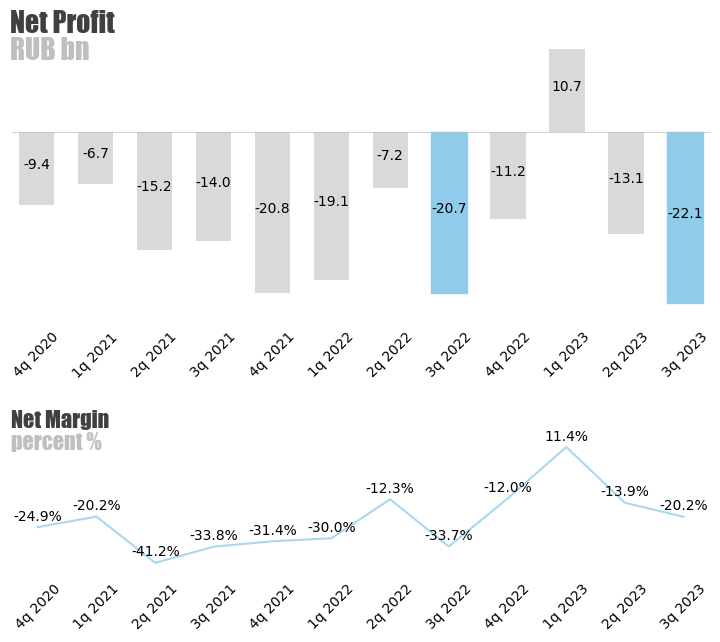

In [13]:
net_margin = val_plq.iloc[18,-12:] / val_plq.iloc[1,-12:] * 100


profit, (prg, prm) = plt.subplots(2,1, figsize=(9,7), height_ratios=(2,1))
prg.text(-0.45, val_plq.iloc[18,-12:].max()*1.2,'Net Profit', fontsize=20, **font, color=f_colors[0])
prg.text(-0.45, val_plq.iloc[18,-12:].max()*0.87,'RUB bn', fontsize=20, **font, color=f_colors[1]) 
prg.xaxis.set_tick_params(rotation=45, labelsize=10)
profit_bars = prg.bar(dates_q, val_plq.iloc[18,-12:], color=f_colors[2], width=0.6)
profit_bars[-1].set_color(colors[3])
profit_bars[-5].set_color(colors[3])
prg.set_ylim(val_plq.iloc[18,-12:].min()*1.1, val_plq.iloc[18,-12:].max()*1.2)
for i in range(val_plq.iloc[18,-12:].shape[0]):
    prg.text(dates_q.iloc[i], val_plq.iloc[18,-12+i]*0.5, str(round(val_plq.iloc[18,-12+i], 1)),
             ha='center', fontsize=10)
prg.yaxis.set_visible(False)
prg.xaxis.set_ticks_position('none')
prg.margins(x=0.01)
for key, spine in prg.spines.items():
    spine.set_visible(False)
prg.axhline(y=0, color=f_colors[1], linewidth=0.5)
plt.subplots_adjust(hspace=0.5)
prm.set_ylim(net_margin.min()*1.1, 20)
prm.plot(dates_q, net_margin, color=colors[3], alpha=0.77)
prm.text(-0.45, 20,'Net Margin', fontsize=16, **font, color=f_colors[0])
prm.text(-0.45, 10,'percent %', fontsize=16, **font, color=f_colors[1]) 
prm.xaxis.set_tick_params(rotation=45, labelsize=10)
prm.yaxis.set_visible(False)
prm.margins(x=0.04)
prm.xaxis.set_ticks_position('none')
for key, spine in prm.spines.items():
    spine.set_visible(False)
for i in range(net_margin.shape[0]):
    prm.text(dates_q.iloc[i], net_margin.iloc[i]+3, str(round(net_margin.iloc[i], 1))+"%",
              ha='center', fontsize=10)


CASH, DEBT, Interest expenses

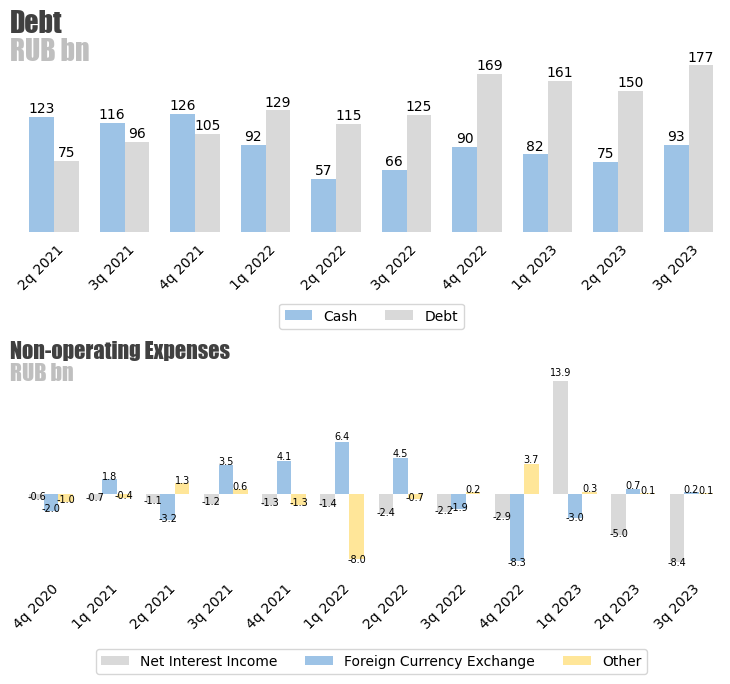

In [14]:
debt_cash = val_fr.iloc[[7,13],-10:] / 1000000
width_debt = 0.35
width_debt2 = 0.25
debt_cash.iloc[1,:]
labels_debt = ['Cash', 'Debt']
labels_debts = ['Net Interest Income', 'Foreign Currency Exchange', 'Other']
nonop_expenses = pd.DataFrame([val_plq.iloc[12,-12:], val_plq.iloc[14,-12:], np.sum(val_plq.iloc[[11,13,15],-12:],axis=0)], index = labels_debts)


debt_analysis, (dag, das) = plt.subplots(2,1, figsize=(9,7))
for i in range(debt_cash.shape[0]):
    dag.bar(dates_line[:-2] + width_debt * i , debt_cash.iloc[i,:], width = width_debt, 
            color=ozon_colors[1-i], label=labels_debt[i])
for i in range(debt_cash.shape[0]):
    for j in range(debt_cash.shape[1]):
        dag.text(dates_line[j] + width_debt * i, debt_cash.iloc[i,j]+5, str(round(debt_cash.iloc[i,j])),
                 ha='center', fontsize=10)
dag.text(-0.45, max(debt_cash.max(axis=1))*1.2,'Debt', fontsize=20, **font, color=f_colors[0])
dag.text(-0.45, max(debt_cash.max(axis=1))*1.03,'RUB bn', fontsize=20, **font, color=f_colors[1]) 
dag.xaxis.set_tick_params(rotation=45, labelsize=10)
dag.yaxis.set_visible(False)
dag.xaxis.set_ticks_position('none')
dag.margins(x=0.01)
dag.set_xticks(dates_line[:-2], dates_q.iloc[2:])
dag.set_ylim(0, max(debt_cash.max(axis=1))*1.2)
for key, spine in dag.spines.items():
    spine.set_visible(False)
dag.legend(loc='lower center', bbox_to_anchor=(0.5, -0.52), ncol=2)
plt.subplots_adjust(hspace=0.7)    
for i in range(nonop_expenses.shape[0]):
    das.bar(dates_line + width_debt2 * i, nonop_expenses.iloc[i], color=ozon_colors[i], label=labels_debts[i], width=width_debt2)
for i in range(nonop_expenses.shape[0]):
    for j in range(nonop_expenses.shape[1]):
        das.text(dates_line[j] + width_debt2 * i, nonop_expenses.iloc[i, j]*1.05, str(round(nonop_expenses.iloc[i,j],1)),
                 ha='center', fontsize=7)
das.text(-0.45, max(nonop_expenses.max())*1.2,'Non-operating Expenses', fontsize=16, **font, color=f_colors[0])
das.text(-0.45, max(nonop_expenses.max())*1,'RUB bn', fontsize=16, **font, color=f_colors[1]) 
das.yaxis.set_visible(False)
das.set_xticks(dates_line, dates_q)
das.xaxis.set_ticks_position('none')
das.xaxis.set_tick_params(rotation=45, labelsize=10)
das.margins(x=0.01)
for key, spine in das.spines.items():
    spine.set_visible(False)
das.legend(loc='lower center', bbox_to_anchor=(0.5, -0.55), ncol=3)



Cashlows

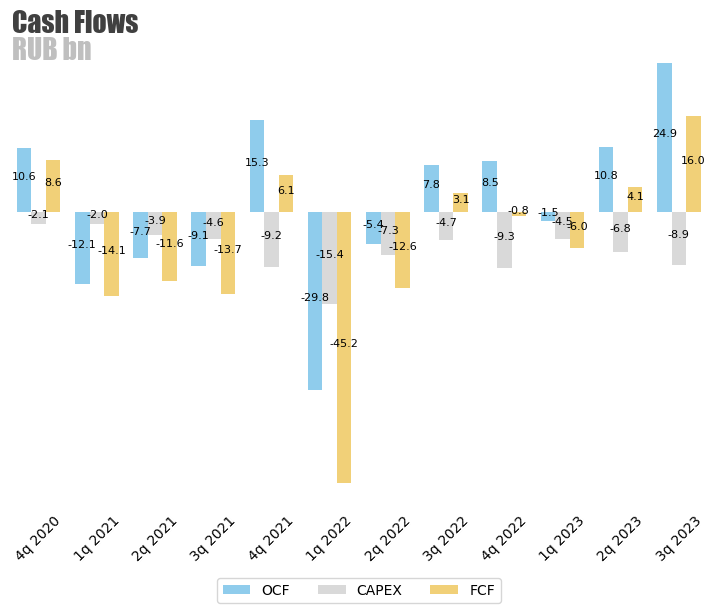

In [16]:
cf_labels = ['OCF', 'CAPEX', 'FCF']
cash_flows = pd.DataFrame([val_cfq.iloc[20, -12:], val_cfq.iloc[41, -12:], val_cfq.iloc[20,-12:] + val_cfq.iloc[41,-12:]], index=cf_labels)
cf_colors = ['#8FCCEC', '#D9D9D9','#F1D078']
cf_width = 0.25


cf_graph, cfg = plt.subplots(figsize=(9,6))
cfg.text(-0.45, max(cash_flows.max(axis=1))*1.2,'Cash Flows', fontsize=20, **font, color=f_colors[0])
cfg.text(-0.45, max(cash_flows.max(axis=1))*1.02,'RUB bn', fontsize=20, **font, color=f_colors[1]) 
cfg.margins(x=0.01)
cfg.set_xticks(dates_line, dates_q)
cfg.yaxis.set_visible(False)
cfg.xaxis.set_tick_params(rotation=45, labelsize=10)
cfg.xaxis.set_ticks_position('none')
cfg.xaxis.set_tick_params(rotation=45, labelsize=10)
cfg.margins(x=0.01)
for key, spine in cfg.spines.items():
    spine.set_visible(False)
for i in range(cash_flows.shape[0]):
    cfg.bar(dates_line + cf_width * (-1+i), cash_flows.iloc[i], label=cf_labels[i], 
            width=cf_width, color=cf_colors[i])
cfg.legend(loc = 'lower center', bbox_to_anchor=(0.5,-0.23), ncol=3)
for i in range(cash_flows.shape[0]):
    for j in range(cash_flows.shape[1]):
        cfg.text(dates_line[j] + cf_width * (-1+i), cash_flows.iloc[i,j]*0.5, str(round(cash_flows.iloc[i,j],1)),
                 ha='center', fontsize=8)

Share of revenue and operating expenses in GMV

(24.16031042128603, 68.49656992084432)

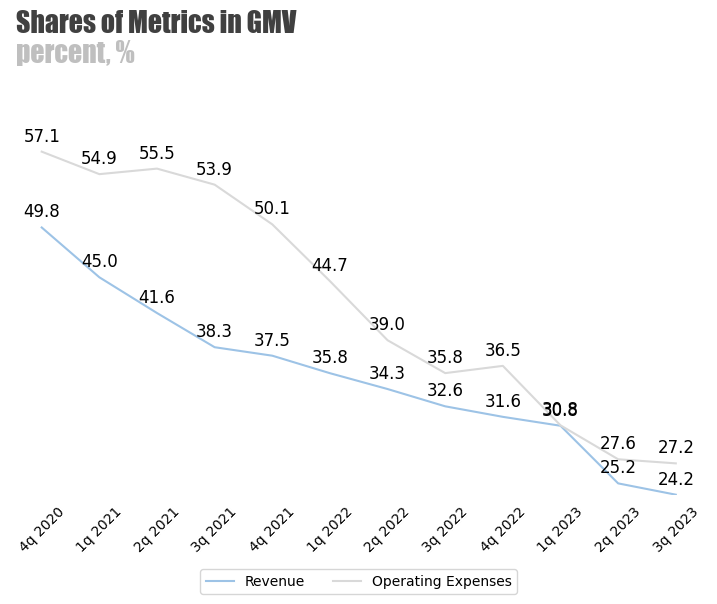

In [17]:
rev_gmv = val_plq.iloc[1, -12:] / np.array(market_place.iloc[1,-12:]) * 100
exp_gmv = -val_plq.iloc[4, -12:] / np.array(market_place.iloc[1,-12:]) * 100
gmv_ratios = pd.DataFrame([rev_gmv, exp_gmv], index=['Revenue', 'Operating Expenses'])


gmv_shares, gmvr = plt.subplots(figsize=(9,6))
for i in range(gmv_ratios.shape[0]):
    gmvr.plot(dates_q, gmv_ratios.iloc[i], label=gmv_ratios.index[i], color=ozon_colors[1-i])
gmvr.xaxis.set_tick_params(rotation=45, labelsize=10)
gmvr.yaxis.set_visible(False)
for key, spine in gmvr.spines.items():
    spine.set_visible(False)
gmvr.xaxis.set_ticks_position('none')
gmvr.legend(loc='lower center', bbox_to_anchor=(0.5, -0.23), ncol=2, fontsize=10)
gmvr.text(-0.45, max(gmv_ratios.max())*1.2, 'Shares of Metrics in GMV', fontsize=20, **font, color=f_colors[0])
gmvr.text(-0.45, max(gmv_ratios.max())*1.15, 'percent, %', fontsize=20, **font, color=f_colors[1])
for i in range(gmv_ratios.shape[0]):
    for j in range(gmv_ratios.shape[1]):
        gmvr.text(dates_q.iloc[j], gmv_ratios.iloc[i,j]+1, str(round(gmv_ratios.iloc[i,j],1)),
                  ha='center', fontsize=12)
gmvr.set_ylim(min(gmv_ratios.min()), max(gmv_ratios.max())*1.2) 



P/S ratio

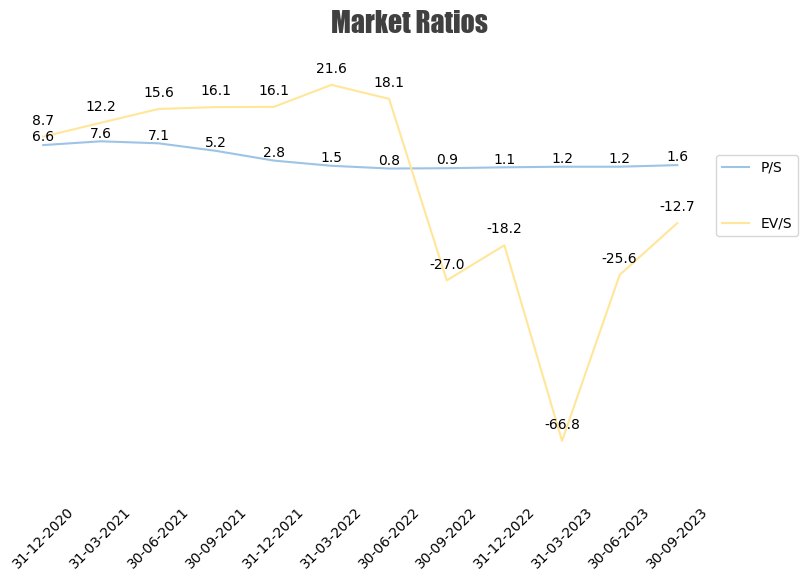

In [18]:
ps_historical, psg = plt.subplots(figsize=(9,6))
psg.plot(val_fr.iloc[0, 1:], val_fr.iloc[31, 1:], label='P/S', color=ozon_colors[1])
psg.plot(val_fr.iloc[0, 1:], val_fr.iloc[32, 1:], label='EV/S', color=ozon_colors[2])
psg.xaxis.set_tick_params(rotation=45, labelsize=10)
psg.yaxis.set_visible(False)
psg.set_ylim(min(val_fr.iloc[[31,32], 1:].min())*1.2, max(val_fr.iloc[[31,32], 1:].max())*1.6)
psg.text(5, max(val_fr.iloc[[31,32], 1:].max())*1.6, 'Market Ratios', fontsize=20, **font, color=f_colors[0])    
for key, spine in psg.spines.items():
    spine.set_visible(False)
psg.xaxis.set_ticks_position('none')
psg.legend(bbox_to_anchor=(1,0.75),labelspacing = 3)
for i in range(len(val_fr.iloc[31, 1:])):
    psg.text(val_fr.iloc[0, 1+i], val_fr.iloc[31, 1+i]+1, str(round(val_fr.iloc[31, 1+i],1))
             , ha='center', fontsize=10)
for i in range(len(val_fr.iloc[32, 1:])):
    psg.text(val_fr.iloc[0, 1+i], val_fr.iloc[32, 1+i]+3, str(round(val_fr.iloc[32, 1+i],1))
             , ha='center', fontsize=10)    
    